<a href="https://colab.research.google.com/github/Manikumar1999/Time-Series-Modelling-Case-Study/blob/main/assigment2_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
# Imports for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time series and evaluation
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep learning components
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Plotting aesthetics
plt.style.use('bmh')


## Load and Preview the Datasets

In [ ]:
# Load datasets
jjData = pd.read_csv("jj.csv")
amznData = pd.read_csv("AMZN.csv")

# Parse dates
jjData['date'] = pd.to_datetime(jjData['date'])
amznData['Date'] = pd.to_datetime(amznData['Date'])

# Sort chronologically
jjData = jjData.sort_values('date')
amznData = amznData.sort_values('Date')

# Print preview
print("J&J Data Sample:")
print(jjData.head(), "\n")

print("Amazon Stock Sample:")
print(amznData.head())


J&J Data Sample:
        date  data
0 1960-01-01  0.71
1 1960-04-01  0.63
2 1960-07-02  0.85
3 1960-10-01  0.44
4 1961-01-01  0.61 

Amazon Stock Sample:
        Date       Open       High        Low      Close  Adj Close     Volume
0 2018-02-20  72.324501  74.438499  72.324501  73.417503  73.417503  129984000
1 2018-02-21  74.250000  75.174500  73.945999  74.146004  74.146004  126088000
2 2018-02-22  74.767998  75.126999  73.788002  74.266998  74.266998   97162000
3 2018-02-23  74.766998  75.000000  74.324997  75.000000  75.000000   88362000
4 2018-02-26  75.459999  76.141998  75.349998  76.097504  76.097504   99100000


## Visual Inspection of Time Series

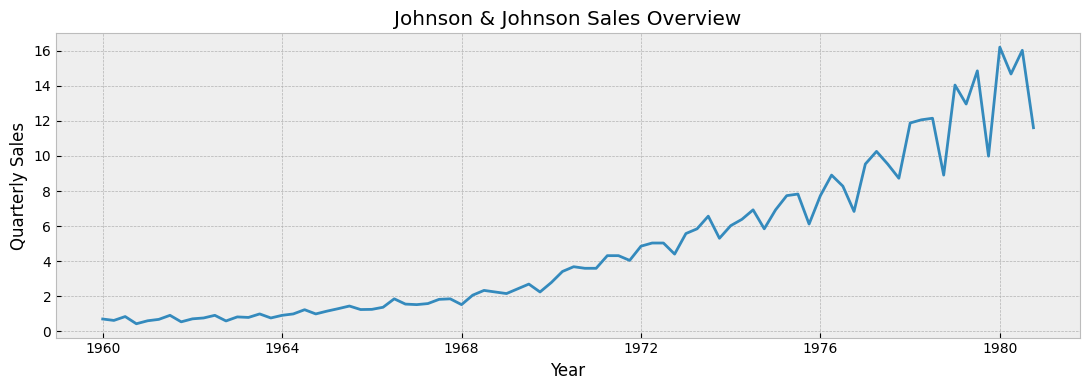

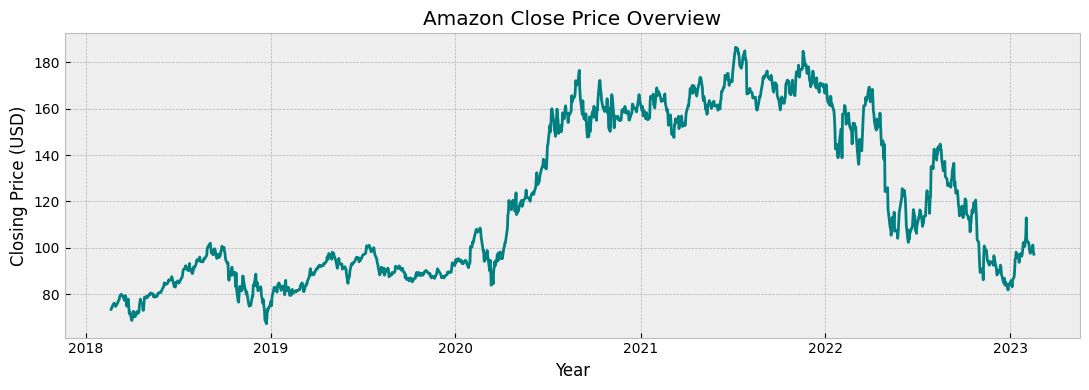

In [ ]:
# Plot for JJ
plt.figure(figsize=(11, 4))
plt.plot(jjData['date'], jjData['data'], linewidth=2)
plt.title('Johnson & Johnson Sales Overview')
plt.xlabel('Year')
plt.ylabel('Quarterly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot for Amazon
plt.figure(figsize=(11, 4))
plt.plot(amznData['Date'], amznData['Close'], color='teal')
plt.title('Amazon Close Price Overview')
plt.xlabel('Year')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()


## Stationarity Tester Function

In [ ]:
# Function to perform ADF test and print summary
def runAdfTest(timeSeries, label):
    print(f"--- ADF Test Results for {label} ---")
    result = adfuller(timeSeries)
    print(f"ADF Stat: {result[0]:.4f}")
    print(f"p-Value: {result[1]:.5f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    print("------------------------------\n")


In [ ]:
# Run ADF on original JJ sales
runAdfTest(jjData['data'], "JJ Sales - Original")

# Apply log + diff
jjData['logSales'] = np.log(jjData['data'])
jjData['logDiff'] = jjData['logSales'].diff()

# Drop NaNs created by differencing
jjDataClean = jjData.dropna()

# ADF on transformed data
runAdfTest(jjDataClean['logDiff'], "JJ Sales - Log Differenced")


--- ADF Test Results for JJ Sales - Original ---
ADF Stat: 2.7420
p-Value: 1.00000
Critical Values:
  1%: -3.5246
  5%: -2.9026
  10%: -2.5887
------------------------------

--- ADF Test Results for JJ Sales - Log Differenced ---
ADF Stat: -4.3170
p-Value: 0.00041
Critical Values:
  1%: -3.5183
  5%: -2.8999
  10%: -2.5872
------------------------------



## Check Amazon Stationarity (Raw vs Log-Diff)

In [ ]:
# Log and diff Amazon 'Close' column
amznData['logClose'] = np.log(amznData['Close'])
amznData['logDiff'] = amznData['logClose'].diff()

# Cleaned version
amznClean = amznData.dropna()

# Run tests
runAdfTest(amznData['Close'], "Amazon Close Price - Original")
runAdfTest(amznClean['logDiff'], "Amazon Close Price - Log Differenced")


--- ADF Test Results for Amazon Close Price - Original ---
ADF Stat: -1.6578
p-Value: 0.45297
Critical Values:
  1%: -3.4356
  5%: -2.8638
  10%: -2.5680
------------------------------

--- ADF Test Results for Amazon Close Price - Log Differenced ---
ADF Stat: -36.6398
p-Value: 0.00000
Critical Values:
  1%: -3.4356
  5%: -2.8638
  10%: -2.5680
------------------------------



## Plot Lag Diagnostics (ACF & PACF)

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def showLagPlots(series, seriesLabel):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(series, ax=axs[0], lags=25, title=f"{seriesLabel} - ACF", alpha=0.05)
    plot_pacf(series, ax=axs[1], lags=25, title=f"{seriesLabel} - PACF", alpha=0.05, method='ywm')

    for ax in axs:
        ax.grid(True)
    plt.suptitle(f"Lag Analysis for {seriesLabel}", fontsize=14)
    plt.tight_layout()
    plt.show()


### Plot for JJ (Log Differenced)

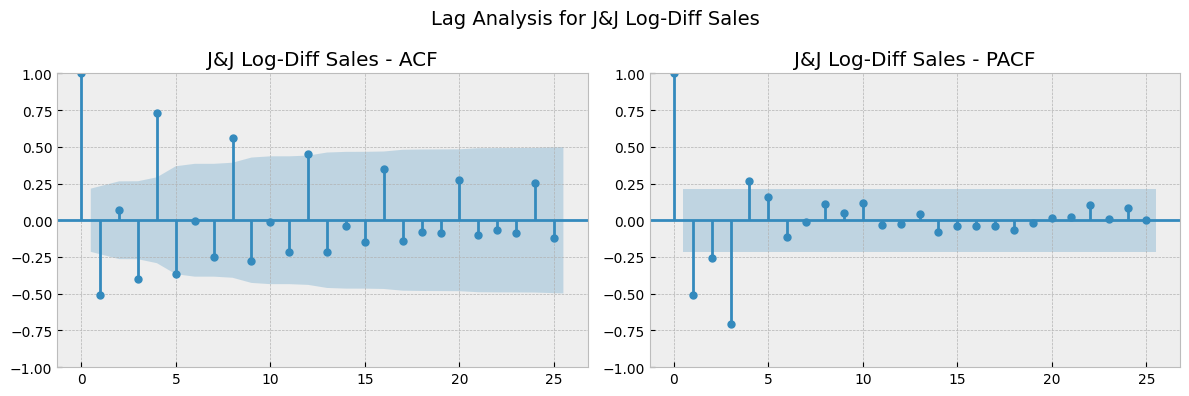

In [ ]:
showLagPlots(jjDataClean['logDiff'], "J&J Log-Diff Sales")


### Plot for Amazon (Log Differenced)

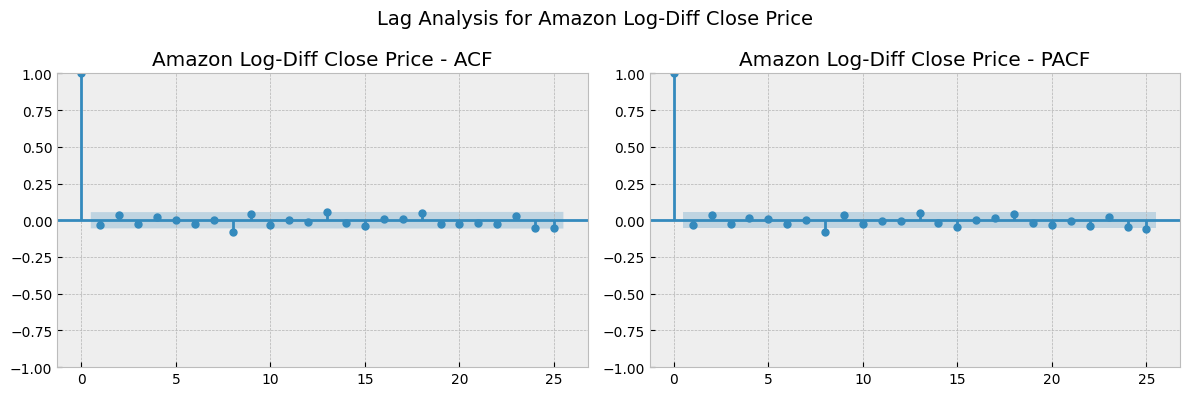

In [ ]:
showLagPlots(amznClean['logDiff'], "Amazon Log-Diff Close Price")


## JJ ARIMA

### Fit ARIMA to JJ Sales (Log-Diff)

In [ ]:
# Fit ARIMA model (customized order)
jjModel = SARIMAX(jjDataClean['logSales'], order=(4, 1, 3), enforce_stationarity=False, enforce_invertibility=False)
jjFitResult = jjModel.fit(disp=False)

# Summary
print(jjFitResult.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               logSales   No. Observations:                   83
Model:               SARIMAX(4, 1, 3)   Log Likelihood                  85.747
Date:                Fri, 11 Apr 2025   AIC                           -155.494
Time:                        06:49:20   BIC                           -136.641
Sample:                             0   HQIC                          -147.947
                                 - 83                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0260      0.082      0.319      0.750      -0.134       0.186
ar.L2          0.0330      0.080      0.412      0.680      -0.124       0.190
ar.L3          0.0653      0.055      1.178      0.2

### JJ Forecast for 24 Quarters

In [ ]:
# Forecast log values for 8 future quarters, which is 24 months
futureSteps = 8
jjForecast = jjFitResult.get_forecast(steps=futureSteps)
jjPredMean = jjForecast.predicted_mean
jjConfInt = jjForecast.conf_int()

# Index for plotting
jjForecastIndex = np.arange(len(jjData), len(jjData) + futureSteps)

# Convert forecast back to original scale
jjForecastOriginal = np.exp(jjPredMean)
jjCI_Lower = np.exp(jjConfInt.iloc[:, 0])
jjCI_Upper = np.exp(jjConfInt.iloc[:, 1])


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


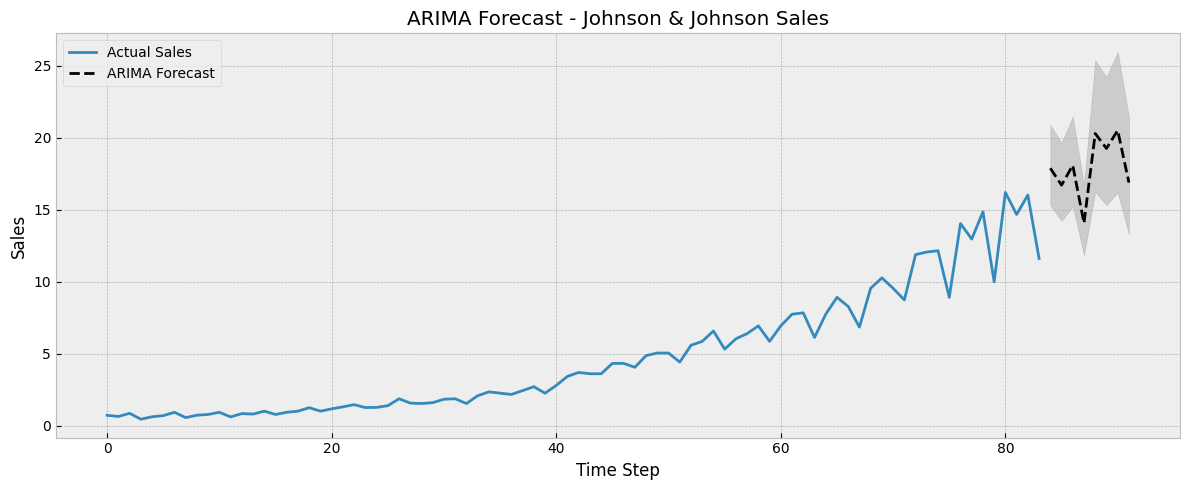

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(jjData['data'], label='Actual Sales', linewidth=2)
plt.plot(jjForecastIndex, jjForecastOriginal, linestyle='--', color='black', label='ARIMA Forecast')

# Confidence interval
plt.fill_between(jjForecastIndex, jjCI_Lower, jjCI_Upper, color='gray', alpha=0.3)

plt.title("ARIMA Forecast - Johnson & Johnson Sales")
plt.xlabel("Time Step")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


##  Amazon ARIMA

### Fit ARIMA to Amazon (Log-Diff)


In [ ]:
# Fit ARIMA to Amazon log-transformed close price
amznModel = SARIMAX(amznClean['logClose'], order=(0, 1, 0), enforce_stationarity=False, enforce_invertibility=False)
amznFitResult = amznModel.fit(disp=False)

# Summary of the model
print(amznFitResult.summary())


                               SARIMAX Results                                
Dep. Variable:               logClose   No. Observations:                 1258
Model:               SARIMAX(0, 1, 0)   Log Likelihood                2965.543
Date:                Fri, 11 Apr 2025   AIC                          -5929.087
Time:                        06:49:30   BIC                          -5923.951
Sample:                             0   HQIC                         -5927.157
                               - 1258                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0005   1.19e-05     43.729      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   1.43   Jarque-Bera (JB):               880.86
Prob(Q):                              0.23   Pr

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


### Forecast Amazon Closing Price (Next 24 Days)

In [ ]:
# Define forecast window
forecastDays = 24
amznForecast = amznFitResult.get_forecast(steps=forecastDays)

# Extract predictions and confidence intervals
amznPredictedLog = amznForecast.predicted_mean
amznConfInt = amznForecast.conf_int()

# Transform back to original scale
amznForecastOriginal = np.exp(amznPredictedLog)
amznLower = np.exp(amznConfInt.iloc[:, 0])
amznUpper = np.exp(amznConfInt.iloc[:, 1])

# Indices for plotting
amznForecastIndex = np.arange(len(amznData), len(amznData) + forecastDays)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
# Define forecast window
forecastDays = 504
amznForecast = amznFitResult.get_forecast(steps=forecastDays)

# Extract predictions and confidence intervals
amznPredictedLog = amznForecast.predicted_mean
amznConfInt = amznForecast.conf_int()

# Transform back to original scale
amznForecastOriginal = np.exp(amznPredictedLog)
amznLower = np.exp(amznConfInt.iloc[:, 0])
amznUpper = np.exp(amznConfInt.iloc[:, 1])

# Indices for plotting
amznForecastIndex = np.arange(len(amznData), len(amznData) + forecastDays)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


###  Plot Amazon ARIMA Forecast

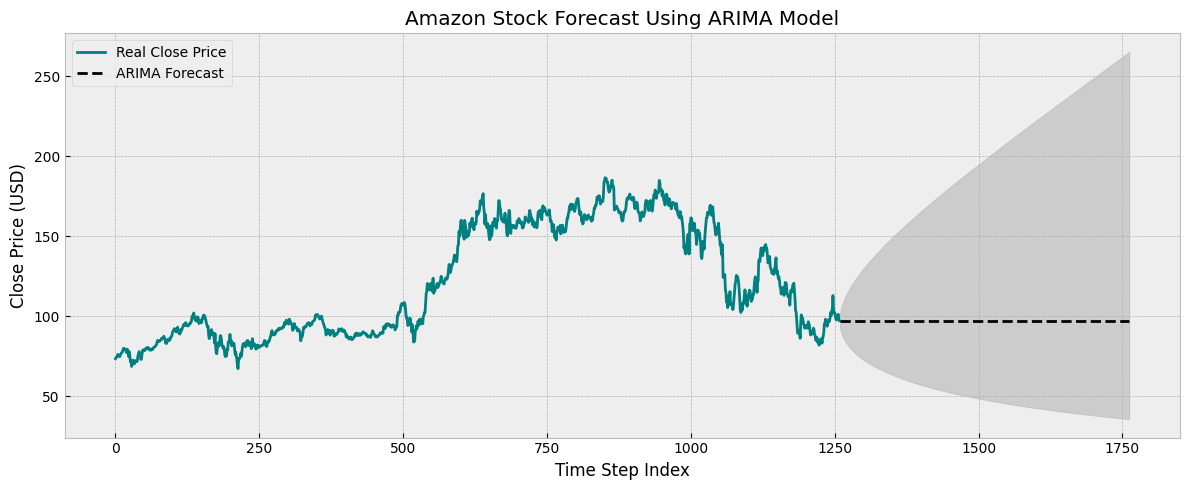

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(amznData['Close'], label='Real Close Price', color='teal')
plt.plot(amznForecastIndex, amznForecastOriginal, linestyle='--', color='black', label='ARIMA Forecast')

plt.fill_between(amznForecastIndex, amznLower, amznUpper, alpha=0.3, color='gray')

plt.title("Amazon Stock Forecast Using ARIMA Model")
plt.xlabel("Time Step Index")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


## ARIMA Evaluation

###  JJ ARIMA Evaluation

In [ ]:
# Forecasted values for JJ (in-sample)
jjFittedLog = jjFitResult.fittedvalues
jjActualLog = jjDataClean['logSales']

# Metrics in log space
jjRmseLog = np.sqrt(mean_squared_error(jjActualLog, jjFittedLog))
jjMaeLog = mean_absolute_error(jjActualLog, jjFittedLog)

# Back-transform to original scale
jjFittedOriginal = np.exp(jjFittedLog)
jjActualOriginal = jjDataClean['data']

jjRmseOriginal = np.sqrt(mean_squared_error(jjActualOriginal, jjFittedOriginal))
jjMaeOriginal = mean_absolute_error(jjActualOriginal, jjFittedOriginal)

print(f"JJ ARIMA RMSE (log): {jjRmseLog:.4f}")
print(f"JJ ARIMA MAE (log): {jjMaeLog:.4f}")
print(f"JJ ARIMA RMSE (original): {jjRmseOriginal:.4f}")
print(f"JJ ARIMA MAE (original): {jjMaeOriginal:.4f}")


JJ ARIMA RMSE (log): 0.1327
JJ ARIMA MAE (log): 0.0854
JJ ARIMA RMSE (original): 0.4219
JJ ARIMA MAE (original): 0.2880


### Amazon ARIMA Evaluation

In [ ]:
# In-sample evaluation for Amazon
amznFittedLog = amznFitResult.fittedvalues
amznActualLog = amznClean['logClose']

# Log scale error
amznRmseLog = np.sqrt(mean_squared_error(amznActualLog, amznFittedLog))
amznMaeLog = mean_absolute_error(amznActualLog, amznFittedLog)

# Transform back to original scale
amznFittedOriginal = np.exp(amznFittedLog)
amznActualOriginal = amznClean['Close']

amznRmseOriginal = np.sqrt(mean_squared_error(amznActualOriginal, amznFittedOriginal))
amznMaeOriginal = mean_absolute_error(amznActualOriginal, amznFittedOriginal)

print(f"Amazon ARIMA RMSE (log): {amznRmseLog:.4f}")
print(f"Amazon ARIMA MAE (log): {amznMaeLog:.4f}")
print(f"Amazon ARIMA RMSE (original): {amznRmseOriginal:.4f}")
print(f"Amazon ARIMA MAE (original): {amznMaeOriginal:.4f}")


Amazon ARIMA RMSE (log): 0.1235
Amazon ARIMA MAE (log): 0.0195
Amazon ARIMA RMSE (original): 3.4491
Amazon ARIMA MAE (original): 1.9740


## JJ LSTM

### Prepping JJ Data for LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Extract and reshape JJ sales data
jjSeries = jjData['data'].values.reshape(-1, 1)

# Normalize the series
jjScaler = MinMaxScaler()
jjScaled = jjScaler.fit_transform(jjSeries)

# Create sequences
def makeSequences(dataArray, lookback=10):
    X, y = [], []
    for idx in range(len(dataArray) - lookback):
        X.append(dataArray[idx:idx + lookback])
        y.append(dataArray[idx + lookback])
    return np.array(X), np.array(y)

# Sequence generation
jjX, jjY = makeSequences(jjScaled, lookback=10)


### JJ Train-Test Split

In [ ]:
# Last 24 points for testing
jjXTrain, jjXTest = jjX[:-24], jjX[-24:]
jjYTrain, jjYTest = jjY[:-24], jjY[-24:]

# Reshape inputs for LSTM
jjXTrain = jjXTrain.reshape(jjXTrain.shape[0], jjXTrain.shape[1], 1)
jjXTest = jjXTest.reshape(jjXTest.shape[0], jjXTest.shape[1], 1)


### Build & Train LSTM Model for JJ

In [ ]:
# LSTM architecture
jjLstmModel = Sequential()
jjLstmModel.add(LSTM(40, activation='tanh', input_shape=(10, 1)))
jjLstmModel.add(Dropout(0.25))
jjLstmModel.add(Dense(1))

jjLstmModel.compile(optimizer='adam', loss='mse')

# Train the model
jjLstmHistory = jjLstmModel.fit(jjXTrain, jjYTrain, epochs=80, validation_data=(jjXTest, jjYTest), verbose=0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Plot JJ LSTM Loss

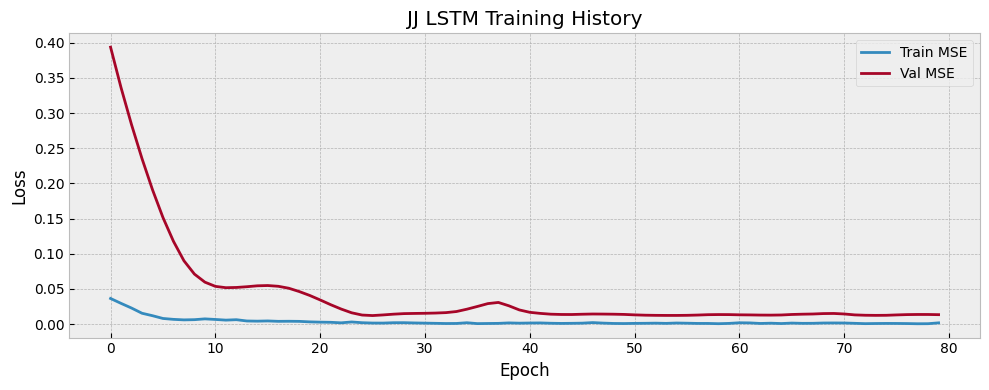

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(jjLstmHistory.history['loss'], label='Train MSE')
plt.plot(jjLstmHistory.history['val_loss'], label='Val MSE')
plt.title("JJ LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Generate JJ LSTM Forecast

In [ ]:
# Reset forecast window
lastInputJj = jjScaled[-10:].reshape(1, 10, 1)

# Updated forecast list for 8 future quarters
jjLstmForecast8 = []

# Predict 8 steps recursively
for _ in range(8):
    nextVal = jjLstmModel.predict(lastInputJj, verbose=0)
    jjLstmForecast8.append(nextVal[0, 0])

    # Update input window
    newVal = nextVal.reshape(1, 1, 1)
    lastInputJj = np.concatenate((lastInputJj[:, 1:, :], newVal), axis=1)


### Back to Original Sales Scale

In [ ]:
# Back to original scale
jjForecastArray8 = np.array(jjLstmForecast8).reshape(-1, 1)
jjForecast8Original = jjScaler.inverse_transform(jjForecastArray8)


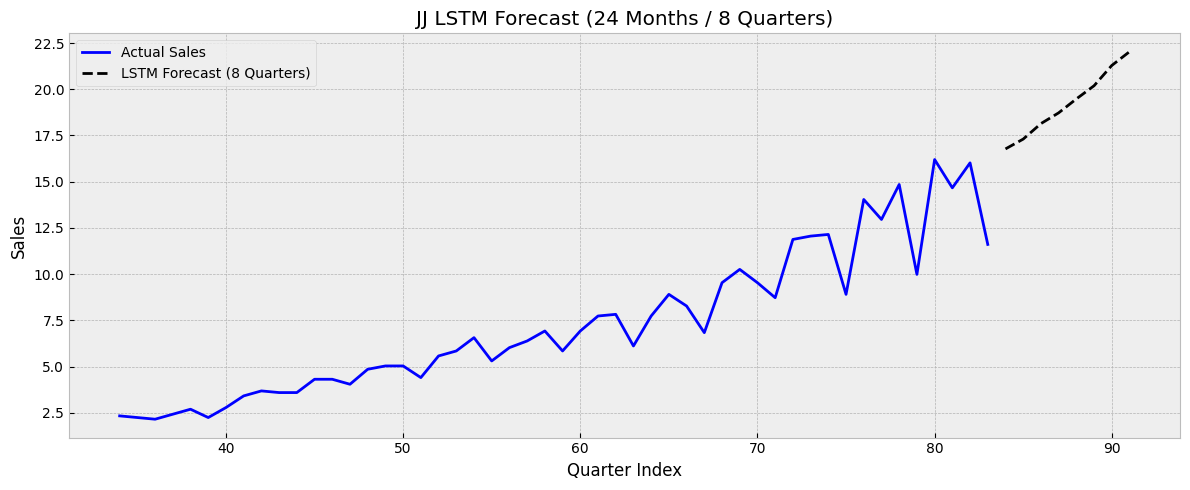

In [ ]:
# Use last 50 actual data points for context
jjActualSeries = jjData['data'].values
recentContext = min(50, len(jjActualSeries))
recentActual = jjActualSeries[-recentContext:]

# Indexing
actualIdx = np.arange(len(jjActualSeries) - recentContext, len(jjActualSeries))
forecastIdx = np.arange(len(jjActualSeries), len(jjActualSeries) + 8)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(actualIdx, recentActual, label="Actual Sales", color="blue")
plt.plot(forecastIdx, jjForecast8Original, linestyle="--", color="black", label="LSTM Forecast (8 Quarters)")

plt.title("JJ LSTM Forecast (24 Months / 8 Quarters)")
plt.xlabel("Quarter Index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### JJ LSTM Evaluation

In [ ]:
# Get actual sales for the next 8 quarters
jjTrueNext8 = jjData['data'].values[-8:]

# Flatten prediction
jjPredNext8 = jjForecast8Original.flatten()

# Evaluation
jjRmse8 = np.sqrt(mean_squared_error(jjTrueNext8, jjPredNext8))
jjMae8 = mean_absolute_error(jjTrueNext8, jjPredNext8)

print(f"JJ LSTM RMSE (8 Qtrs): {jjRmse8:.4f}")
print(f"JJ LSTM MAE  (8 Qtrs): {jjMae8:.4f}")


JJ LSTM RMSE (8 Qtrs): 6.0313
JJ LSTM MAE  (8 Qtrs): 5.4488


## AMAZON LSTM

### Prepare Amazon Data for LSTM

In [ ]:
# Scale 'Close' values
amznCloseValues = amznData[['Close']].values
scalerAmzn = MinMaxScaler()
amznScaled = scalerAmzn.fit_transform(amznCloseValues)

# Create sequences
seqLength = 60
XAmzn, yAmzn = [], []

for i in range(seqLength, len(amznScaled)):
    XAmzn.append(amznScaled[i - seqLength:i])
    yAmzn.append(amznScaled[i])

XAmzn = np.array(XAmzn)
yAmzn = np.array(yAmzn)

### Train-Test Split for Amazon


In [ ]:
forecastHorizon = 504
splitIndex = len(XAmzn) - forecastHorizon

XTrainAmzn = XAmzn[:splitIndex]
yTrainAmzn = yAmzn[:splitIndex]
XTestAmzn = XAmzn[splitIndex:]
yTestAmzn = yAmzn[splitIndex:]

### Build and Train Amazon LSTM

In [ ]:
# Define and train LSTM model
modelAmzn = Sequential()
modelAmzn.add(LSTM(64, return_sequences=False, input_shape=(XAmzn.shape[1], 1)))
modelAmzn.add(Dense(1))

modelAmzn.compile(optimizer='adam', loss='mean_squared_error')
historyAmzn = modelAmzn.fit(XTrainAmzn, yTrainAmzn, epochs=100, batch_size=32, verbose=1)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0591
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0052
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0017
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0014
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0012
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0012
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0010    
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0011
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0011
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0012
Epoch 13/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0010
Epoch 14/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0012
Epoch 15/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.00

### Plot Training and Validation Loss

### Predict 24 Future Amazon Price

Forecast 24 months = ~504 trading days (assuming ~21 trading days per month)

### Predict 24 months

In [ ]:
# Forecast future 504 trading days
lastInputAmzn = amznScaled[-seqLength:].reshape(1, seqLength, 1)
futurePredsScaled = []

for _ in range(forecastHorizon):
    nextPred = modelAmzn.predict(lastInputAmzn, verbose=0)[0]
    futurePredsScaled.append(nextPred)
    lastInputAmzn = np.append(lastInputAmzn[:, 1:, :], [[nextPred]], axis=1)

futurePreds = scalerAmzn.inverse_transform(np.array(futurePredsScaled))

### Inverse Transform

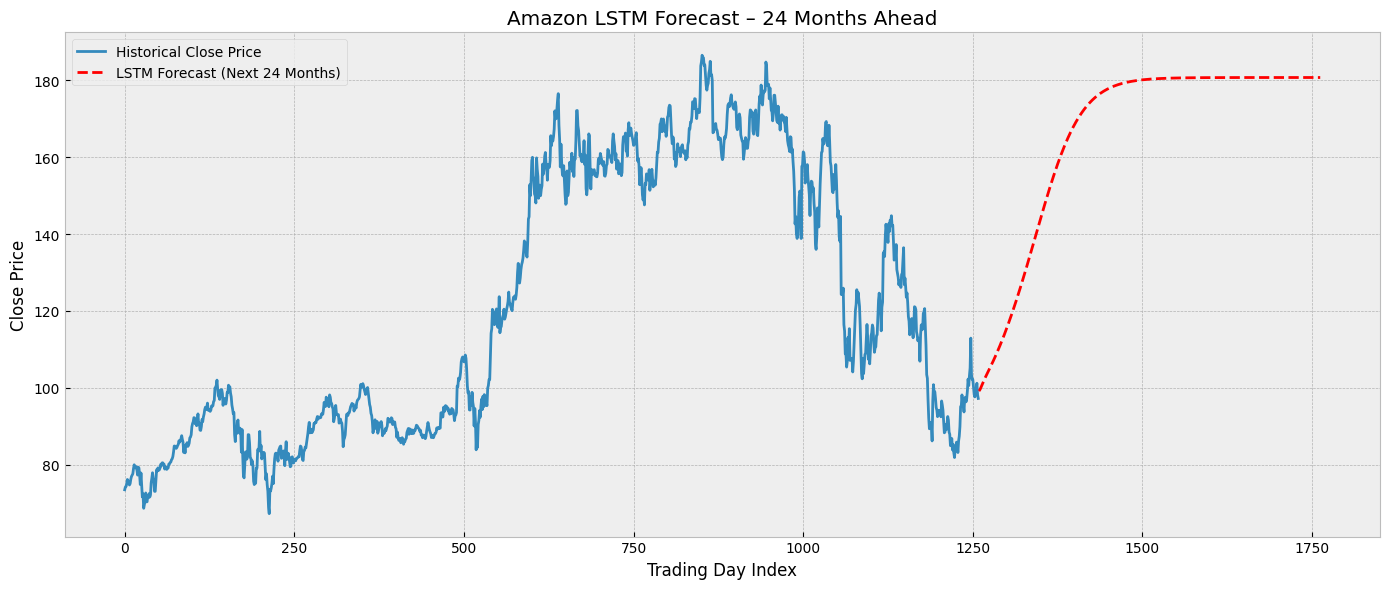

In [ ]:
# Plot forecast
forecastIndex = np.arange(len(amznData), len(amznData) + forecastHorizon)

plt.figure(figsize=(14, 6))
plt.plot(amznData['Close'], label='Historical Close Price')
plt.plot(forecastIndex, futurePreds, 'r--', label='LSTM Forecast (Next 24 Months)')
plt.title('Amazon LSTM Forecast – 24 Months Ahead')
plt.xlabel('Trading Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on test set
testPredsScaled = modelAmzn.predict(XTestAmzn)
testPreds = scalerAmzn.inverse_transform(testPredsScaled)
trueYTest = scalerAmzn.inverse_transform(yTestAmzn)

rmseAmzn = np.sqrt(mean_squared_error(trueYTest, testPreds))
maeAmzn = mean_absolute_error(trueYTest, testPreds)

print("Amazon LSTM Test RMSE:", rmseAmzn)
print("Amazon LSTM Test MAE:", maeAmzn)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Amazon LSTM Test RMSE: 3.9554605108773404
Amazon LSTM Test MAE: 3.02150660231236
